###Loading Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('data/ab_data.csv')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


### Cleaning Duplicated Data

In [7]:
df.drop_duplicates(['user_id'], inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 290584 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       290584 non-null  int64
 1   timestamp     290584 non-null  str  
 2   group         290584 non-null  str  
 3   landing_page  290584 non-null  str  
 4   converted     290584 non-null  int64
dtypes: int64(2), str(3)
memory usage: 13.3 MB


In [9]:
df.groupby(['group']).describe()

user_id                                                    \
              count           mean           std       min        25%   
group                                                                   
control    145232.0  788143.414241  91294.930980  630002.0  709260.75   
treatment  145352.0  787866.452577  91154.647676  630000.0  708757.75   

                                         converted                           \
                50%        75%       max     count      mean       std  min   
group                                                                         
control    788107.5  867179.25  945998.0  145232.0  0.120297  0.325310  0.0   
treatment  787905.5  866740.50  945999.0  145352.0  0.118843  0.323604  0.0   

                               
           25%  50%  75%  max  
group                          
control    0.0  0.0  0.0  1.0  
treatment  0.0  0.0  0.0  1.0

In [10]:
df.groupby(['group']).agg({'converted' : ['sum', 'count', 'mean']})

converted                  
                sum   count      mean
group                                
control       17471  145232  0.120297
treatment     17274  145352  0.118843

In [11]:
df[['group', 'converted']].groupby(['group']).agg('mean').T

group,control,treatment
converted,0.120297,0.118843


### Calculate Prob. of New and Old Pages Respectively

In [16]:
p_old = df[['group','converted']].query("group=='control'")['converted'].mean()
p_new = df[['group', 'converted']].query("group == 'treatment'")['converted'].mean()
act_p_diff = p_new - p_old
print('p_old:\t{}\np_new:\t{}\np_diff:\t{}'.format(p_old, p_new, act_p_diff))

p_old:	0.12029717968491792
p_new:	0.11884253398646046
p_diff:	-0.001454645698457463


### Calculate Counts of New and Old Pages Respectively

In [19]:
n_old = len(df[['group']].query("group=='control'"))
n_new = len(df[['group']].query("group=='treatment'"))
print('n_old:\t{}\nn_new:\t{}'.format(n_old, n_new))

n_old:	145232
n_new:	145352


In [21]:
p_diffs = []

for _ in range(10000):
    new_page_converted = np.random.choice([1, 0], size=n_new, p=[p_new, (1 - p_new)]).mean()
    old_page_converted = np.random.choice([1, 0], size=n_old, p=[p_old, (1 - p_old)]).mean()
    diff = new_page_converted - old_page_converted
    p_diffs.append(diff)

Text(0.5, 1.0, 'Plot of 10K simulated p_diffs')

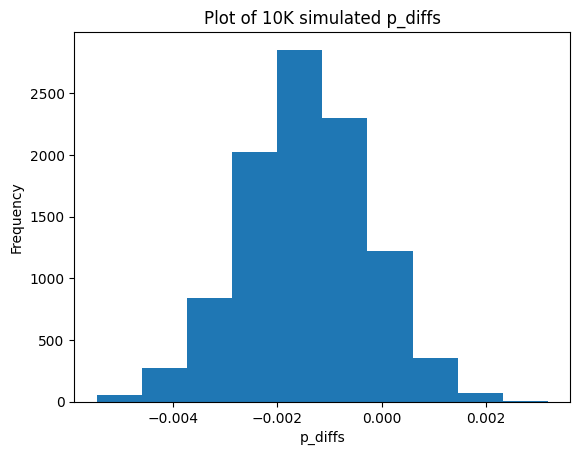

In [22]:
plt.hist(p_diffs)
plt.xlabel('p_diffs')
plt.ylabel('Frequency')
plt.title('Plot of 10K simulated p_diffs')